In [135]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [136]:
print('hi')

hi


In [137]:
from astropy.table import Table

tbl = Table.read('master_table.fits')

# Separate multidimensional columns (e.g. FullPeriodogram) from scalar columns
scalar_cols = [name for name in tbl.colnames if len(tbl[name].shape) <= 1]
multi_cols  = [name for name in tbl.colnames if len(tbl[name].shape) >  1]

master_table = tbl[scalar_cols].to_pandas()

# Keep multidimensional columns as numpy arrays
for col in multi_cols:
    master_table[col] = list(tbl[col])

print(master_table.columns.tolist())

['name', 'rms', 'std', 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio', 'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks', 'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation', 'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power', 'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power', 'Entropy', 'sectors', 'cadence', 'n_sectors', 'LOC', 'AGE', 'FullPeriodogram']


In [138]:
from vis_statistics import plot_cluster_statistics, plot_clusters_comparison
from vis_lc import get_lc_path, plot_cluster_lcs
from vis_periodogram import plot_cluster_periodograms, plot_cluster_periodograms_specific

In [14]:
master_table

,name,rms,std,MAD,sigmaG,skewness,von_neumann_ratio,J_Stetson,max_power,freq_at_max_power,...,SumLSP_7_4_Day_Power,SumLSP_4_1_Day_Power,SumLSP_1_p5_Day_Power,Entropy,sectors,cadence,n_sectors,LOC,AGE,FullPeriodogram
0,b'BMG32',0.061409,0.000668,0.000434,0.000639,3.970871e-01,0.000783,0.935988,0.046111,0.36,...,0.206012,0.528081,0.173964,6.981934,[0],30.0,1,b'LMC',7.90,"[0.026436947727934403, 0.02746316684230981, 0...."
1,b'BMG32',0.161769,0.001006,0.000719,0.001065,-3.085452e+00,0.001452,1.434224,0.174483,0.32,...,0.170952,1.841990,0.271482,6.934397,[1],30.0,1,b'LMC',7.90,"[0.002725964423310637, 0.007146544857656363, 0..."
2,b'BMG32',0.112893,0.001003,0.000626,0.000927,1.726673e+01,0.001003,1.377425,0.174913,0.19,...,0.702348,1.005133,0.103512,7.047517,[2],30.0,1,b'LMC',7.90,"[0.05205991154852454, 0.07989218713552883, 0.0..."
3,b'BMG32',0.119027,0.001056,0.000722,0.001067,-2.638127e+00,0.001146,1.451241,0.112790,0.37,...,0.451855,1.091927,0.113481,7.156956,[3],30.0,1,b'LMC',7.90,"[0.0703332776487653, 0.05668259486342891, 0.03..."
4,b'BMG32',0.061409,0.000850,0.000546,0.000811,-1.767441e+00,0.000560,1.179916,0.068967,0.37,...,0.100536,0.647467,0.117497,7.651595,"[0, 1]",30.0,2,b'LMC',7.90,"[0.006778285831005086, 0.013017152060444029, 0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,b'SAURER 6',0.076887,0.000224,0.000127,0.000192,4.576777e+05,0.000249,1.855109,0.100442,0.64,...,0.044051,0.358435,0.401129,8.793309,"[2, 3]",10.0,2,b'MW',9.20,"[0.003059768275211896, 0.0019877655505533554, ..."
864,b'SAURER 6',0.076887,0.000207,0.000122,0.000183,2.819127e+05,0.000142,1.718202,0.047905,0.64,...,0.031264,0.185120,0.227934,9.234838,"[1, 2, 3]",10.0,3,b'MW',9.20,"[0.0007111998397504028, 0.005050553948971189, ..."
865,b'VDBERGH-HAGEN 92',0.145344,0.000123,0.000069,0.000103,-2.197869e+05,0.001158,3.094980,0.118016,0.24,...,0.474434,1.095533,0.325441,6.988413,[0],30.0,1,b'MW',8.91,"[0.10642368889144069, 0.07384800013195789, 0.0..."
866,b'VDBERGH-HAGEN 92',0.125236,0.000231,0.000103,0.000154,-5.541957e+07,0.001878,3.828865,0.140280,0.11,...,0.424870,0.614386,0.252888,7.047517,[1],30.0,1,b'MW',8.91,"[0.14028026687063624, 0.09835332967226695, 0.0..."


In [25]:
unique_clusters = master_table[['name', 'AGE']].drop_duplicates(subset='name')
unique_clusters = unique_clusters.sort_values('AGE')
unique_clusters

,name,AGE
845,b'RUPRECHT 83',6.400
745,b'CZERNIK 13',6.855
754,b'FSR 0165',6.910
751,b'FSR 0154',7.000
777,b'IC 4996',7.150
809,b'NGC 2910',7.200
493,b'NGC2118',7.200
97,b'NGC1711',7.200
90,b'KMHK1378',7.400
220,b'NGC2093',7.700


In [169]:
print(np.unique(master_table['name']))
print(len(np.unique(master_table['name'])))

[b'ASCC 116' b'ASCC 57' b'BASEL 12' b'BASEL 13' b'BERKELEY 50'
 b'BERKELEY 66' b'BERKELEY 83' b'BERKELEY 85' b'BMG32' b'BSDL2934'
 b'CZERNIK 13' b'Cl Kron 27' b'ESO 130-13' b'FSR 0154' b'FSR 0165'
 b'FSR 0167' b'FSR 0333' b'FSR 0951' b'IC 1311' b'IC 4996' b'KING 1'
 b'KMHK1292' b'KMHK1378' b'KRONBERGER 31' b'LODEN 481' b'LYNGA 2'
 b'LYNGA 4' b'NGC 2671' b'NGC 2910' b'NGC 4103' b'NGC 6883' b'NGC 6885'
 b'NGC 7086' b'NGC 7175' b'NGC1711' b'NGC1735' b'NGC2093' b'NGC2095'
 b'NGC2114' b'NGC2117' b'NGC2118' b'NGC2130' b'NGC2135' b'NGC2153'
 b'NGC2160' b'NGC2177' b'OGLE-CL SMC  297' b'PATCHICK 75' b'RUPRECHT 172'
 b'RUPRECHT 83' b'SAI 132' b'SAURER 6' b'VDBERGH-HAGEN 92' b'[SL63] 730'
 b'[SL63] 741']
55


# Visualize Single Cluster

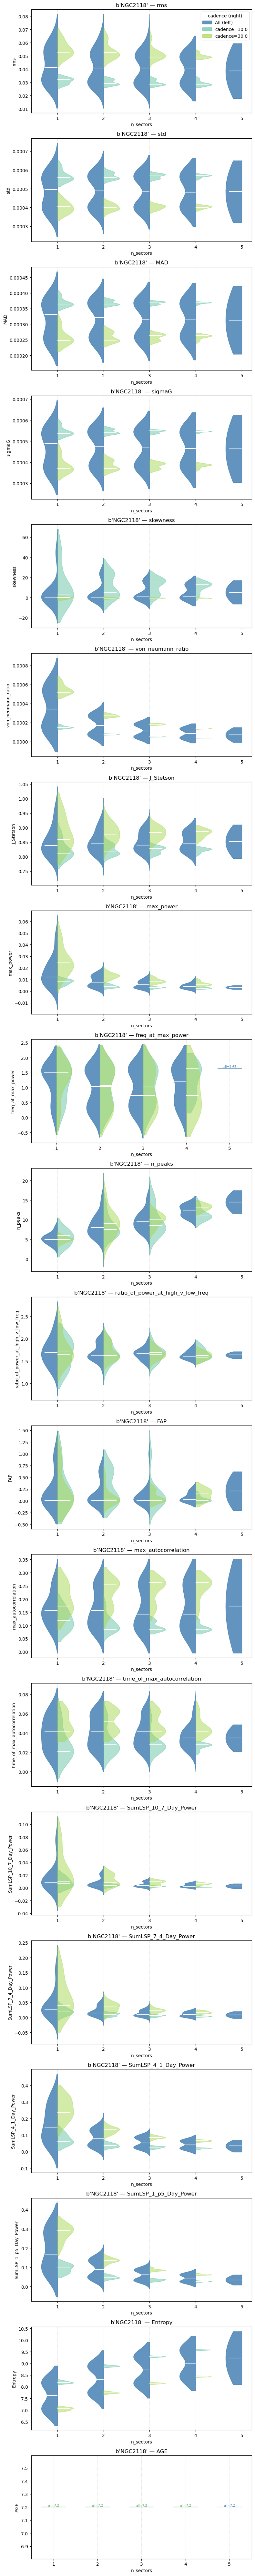

In [9]:
cluster_name = b'NGC2118'
plot_cluster_statistics(
  master_table,
  name=cluster_name,
  statistics_list=['rms', 'std', 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio', 'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks', 'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation', 'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power', 'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power', 'Entropy', 'AGE'],
  max_n_sectors=6
)

# Visualize Single Statistic

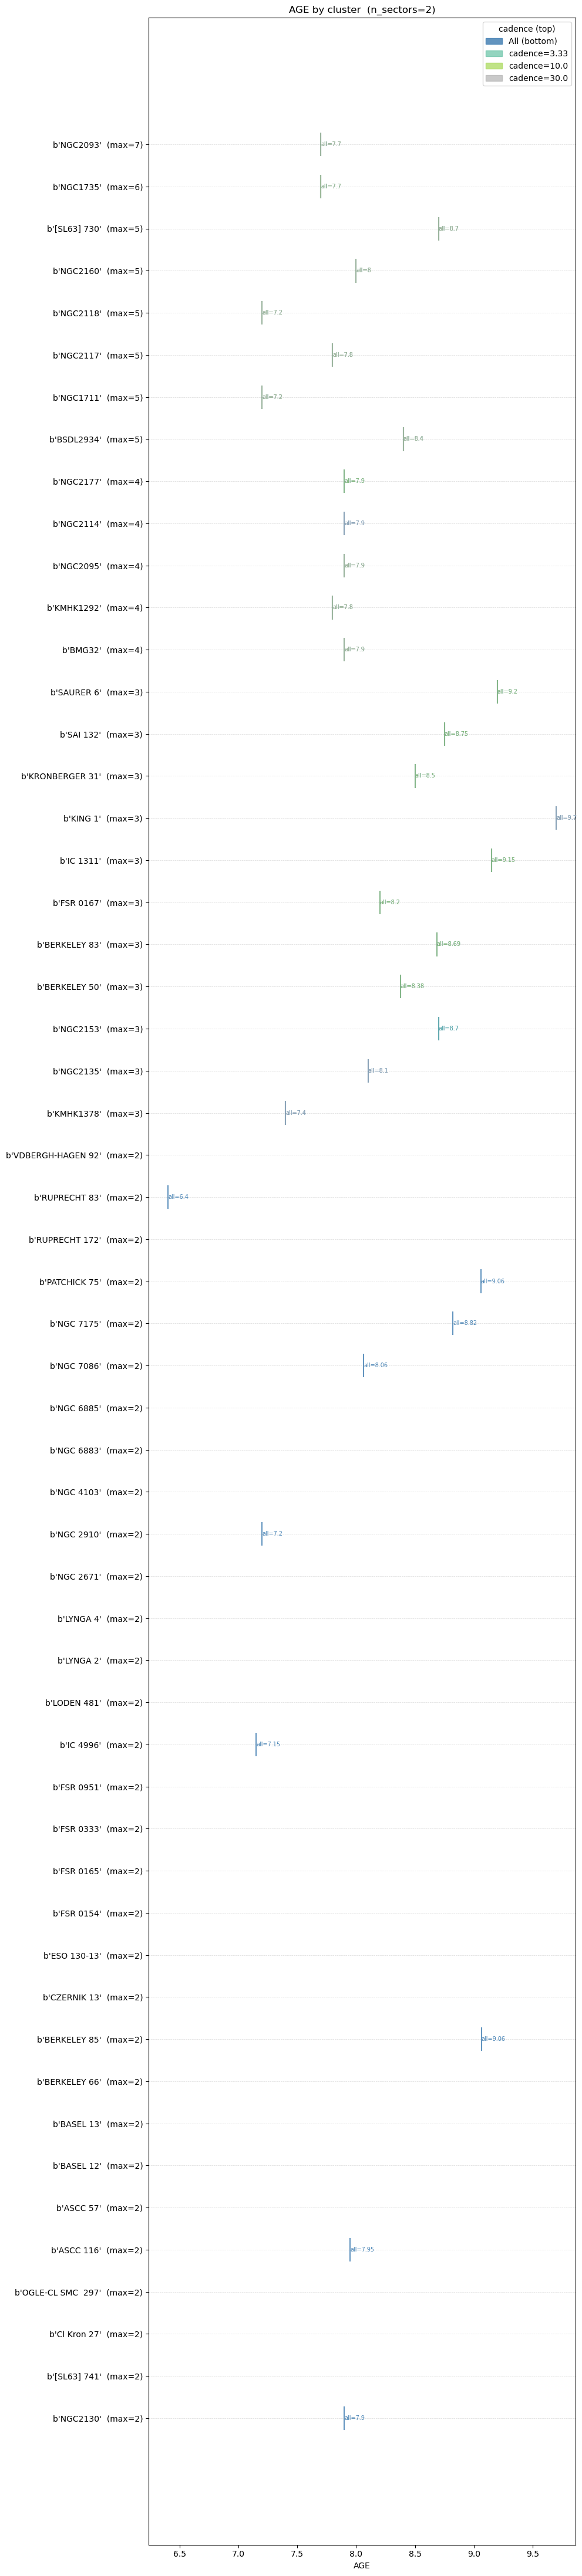

In [18]:
plot_clusters_comparison(master_table, 2, 'AGE', max_clusters=None)

In [ ]:
plot_clusters_comparison(master_table, 1, 'SumLSP_1_p5_Day_Power', max_clusters=None)

In [ ]:
plot_clusters_comparison(master_table, 1, 'skewness', max_clusters=None)

# LC's

[(2061.85866148, 8387.89355469, 4.34856558, 10.63109587, 0.00056288)
 (2061.86560588, 8387.61621094, 4.34968567, 10.63113177, 0.00056305)
 (2061.87255027, 8381.95410156, 4.35281992, 10.63186495, 0.00056383) ...
 (2087.08060164, 8379.83886719, 6.59629536, 10.63213898, 0.00085465)
 (2087.08754598, 8374.72558594, 6.59040022, 10.63280168, 0.00085441)
 (2087.09449033, 8379.04589844, 6.5825429 , 10.63224172, 0.00085295)]
3449


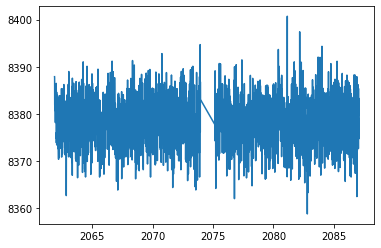

In [152]:
from astropy.table import Table

path = '/astro/users/cgwill/TESS_Cluster_Age_ML/light_curves/LMC/hlsp_elk_tess_ffi_ngc-2118_tess_v1_llc.fits'
sector = 6
with fits.open(path) as hdul:
   LC = hdul[sector].data

print(LC)
print(len(LC['time']))
    
plt.plot(LC['time'], LC['flux'])



In [28]:
unique_clusters

,name,AGE
845,b'RUPRECHT 83',6.400
745,b'CZERNIK 13',6.855
754,b'FSR 0165',6.910
751,b'FSR 0154',7.000
777,b'IC 4996',7.150
809,b'NGC 2910',7.200
493,b'NGC2118',7.200
97,b'NGC1711',7.200
90,b'KMHK1378',7.400
220,b'NGC2093',7.700


In [131]:
#cluster_name = b'RUPRECHT 83' #6.4
#cluster_name = b'CZERNIK 13'  #6.8
#cluster_name = b'FSR 0165'  #6.9
#cluster_name = b'FSR 0154'  #7
#cluster_name = b'FSR 0154'  #7

#cluster_name = b'NGC2118'     #7.2   ##!!!
cluster_name = b'KING 1'      #9.7
#cluster_name = b'BERKELEY 83' #9


i= master_table['name']==cluster_name

print('\n', master_table['sectors'][i])
print('\n', master_table['name'][i])
print('\n', master_table['cadence'][i])



 783          [0]
784          [1]
785          [2]
786       [0, 1]
787       [0, 2]
788       [1, 2]
789    [0, 1, 2]
Name: sectors, dtype: object

 783    b'KING 1'
784    b'KING 1'
785    b'KING 1'
786    b'KING 1'
787    b'KING 1'
788    b'KING 1'
789    b'KING 1'
Name: name, dtype: object

 783    30.0
784    30.0
785    30.0
786    30.0
787    30.0
788    30.0
789    30.0
Name: cadence, dtype: float64


KING 1  —  4 HDU(s)  —  /astro/users/cgwill/TESS_Cluster_Age_ML/light_curves/MW/hlsp_elk_tess_ffi_king-1_tess_v1_llc.fits
  HDU 0: PRIMARY       SECTOR=—     TIMEDEL=—           nrows=0
  HDU 1:               SECTOR=17    TIMEDEL=—           nrows=1126
  HDU 2:               SECTOR=18    TIMEDEL=—           nrows=1103
  HDU 3:               SECTOR=24    TIMEDEL=—           nrows=1224
  HDU 4:               SECTOR=58    TIMEDEL=—           nrows=11692


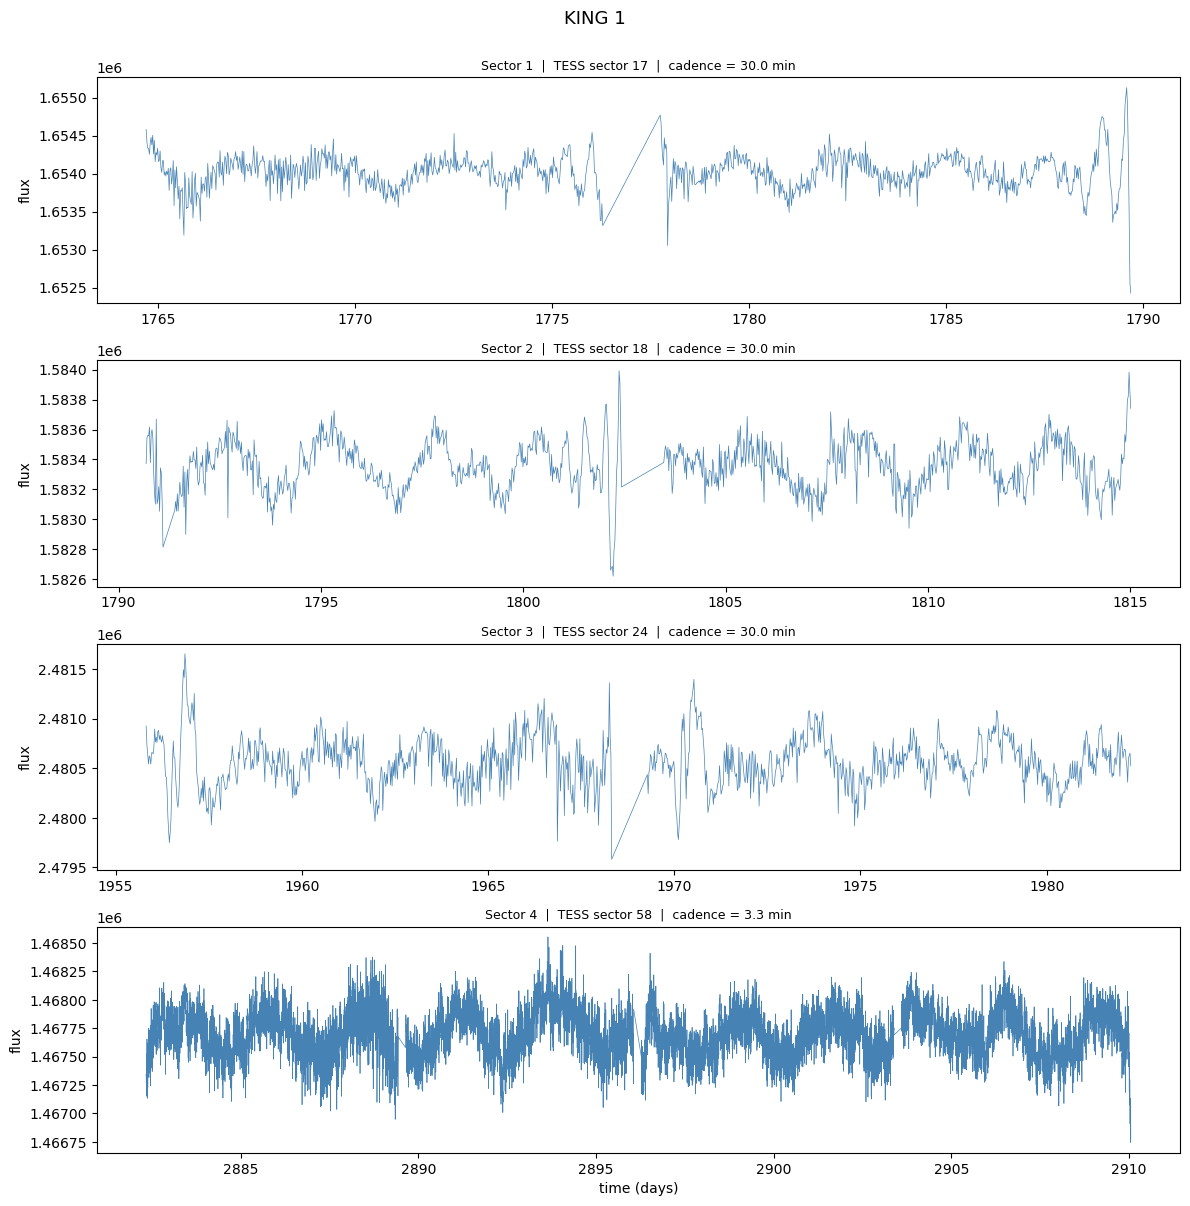

In [132]:
plot_cluster_lcs(master_table, cluster_name) #looks up the raw LC file and shows it.

## Periodogram

In [133]:
PG = master_table['FullPeriodogram'][i]
PG

783    [0.002430258306066143, 0.005090182888254831, 0...
784    [0.008851773140129717, 0.012358753196813354, 0...
785    [0.002040277650236503, 0.001021549571517546, 0...
786    [0.0056193404593099985, 0.0045326843822844215,...
787    [0.002038537766071908, 0.0017593540744814955, ...
788    [0.004147622016737927, 0.0012964405807604942, ...
789    [0.0038013995008443465, 0.0011354085240883158,...
Name: FullPeriodogram, dtype: object

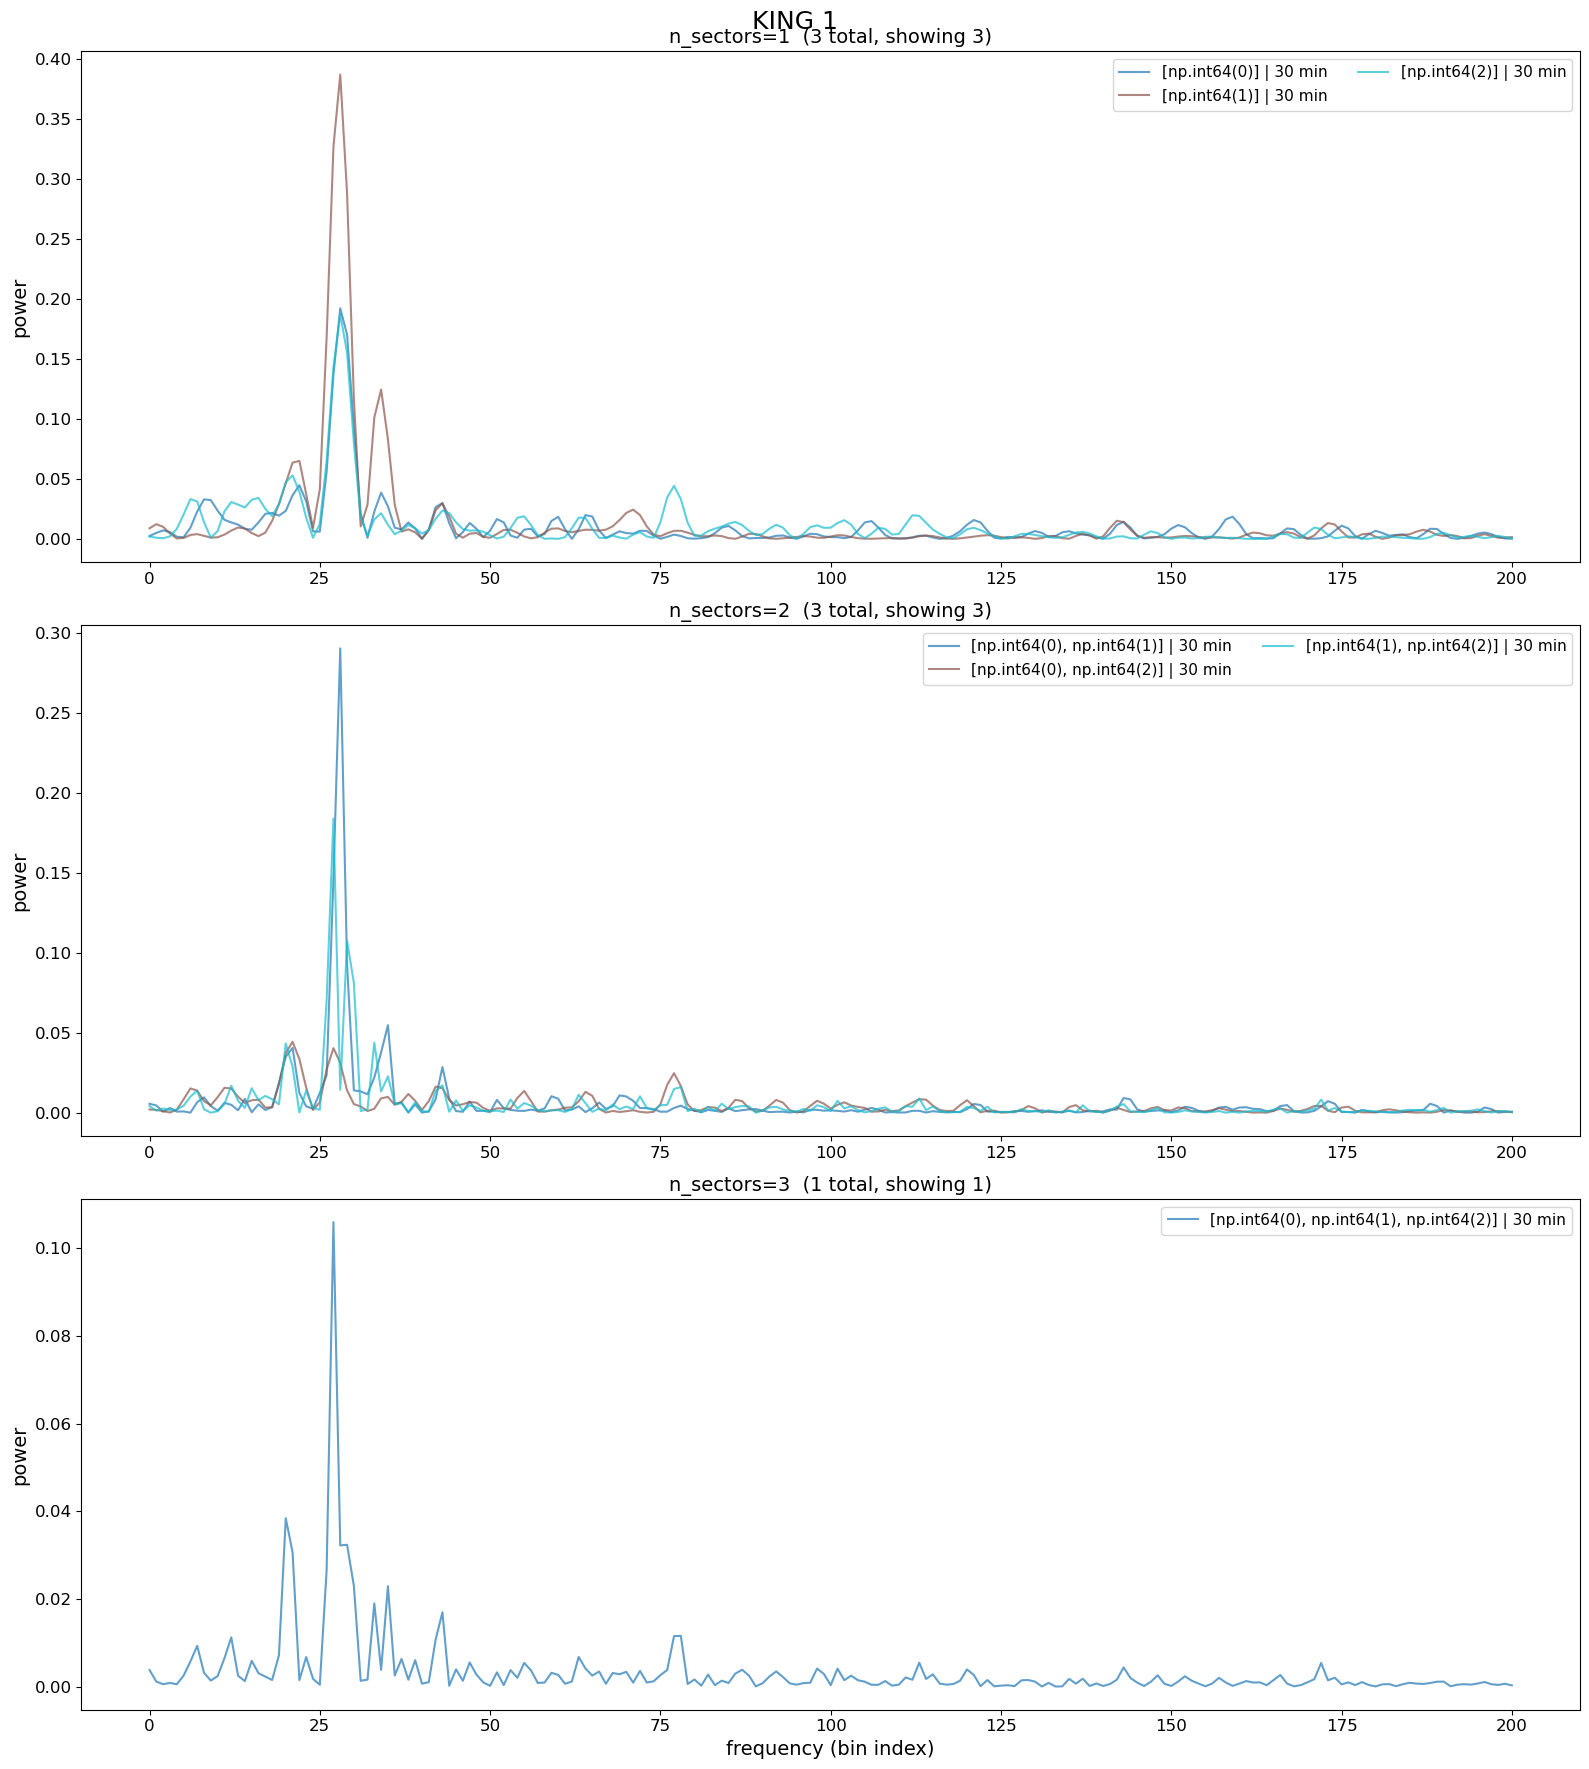

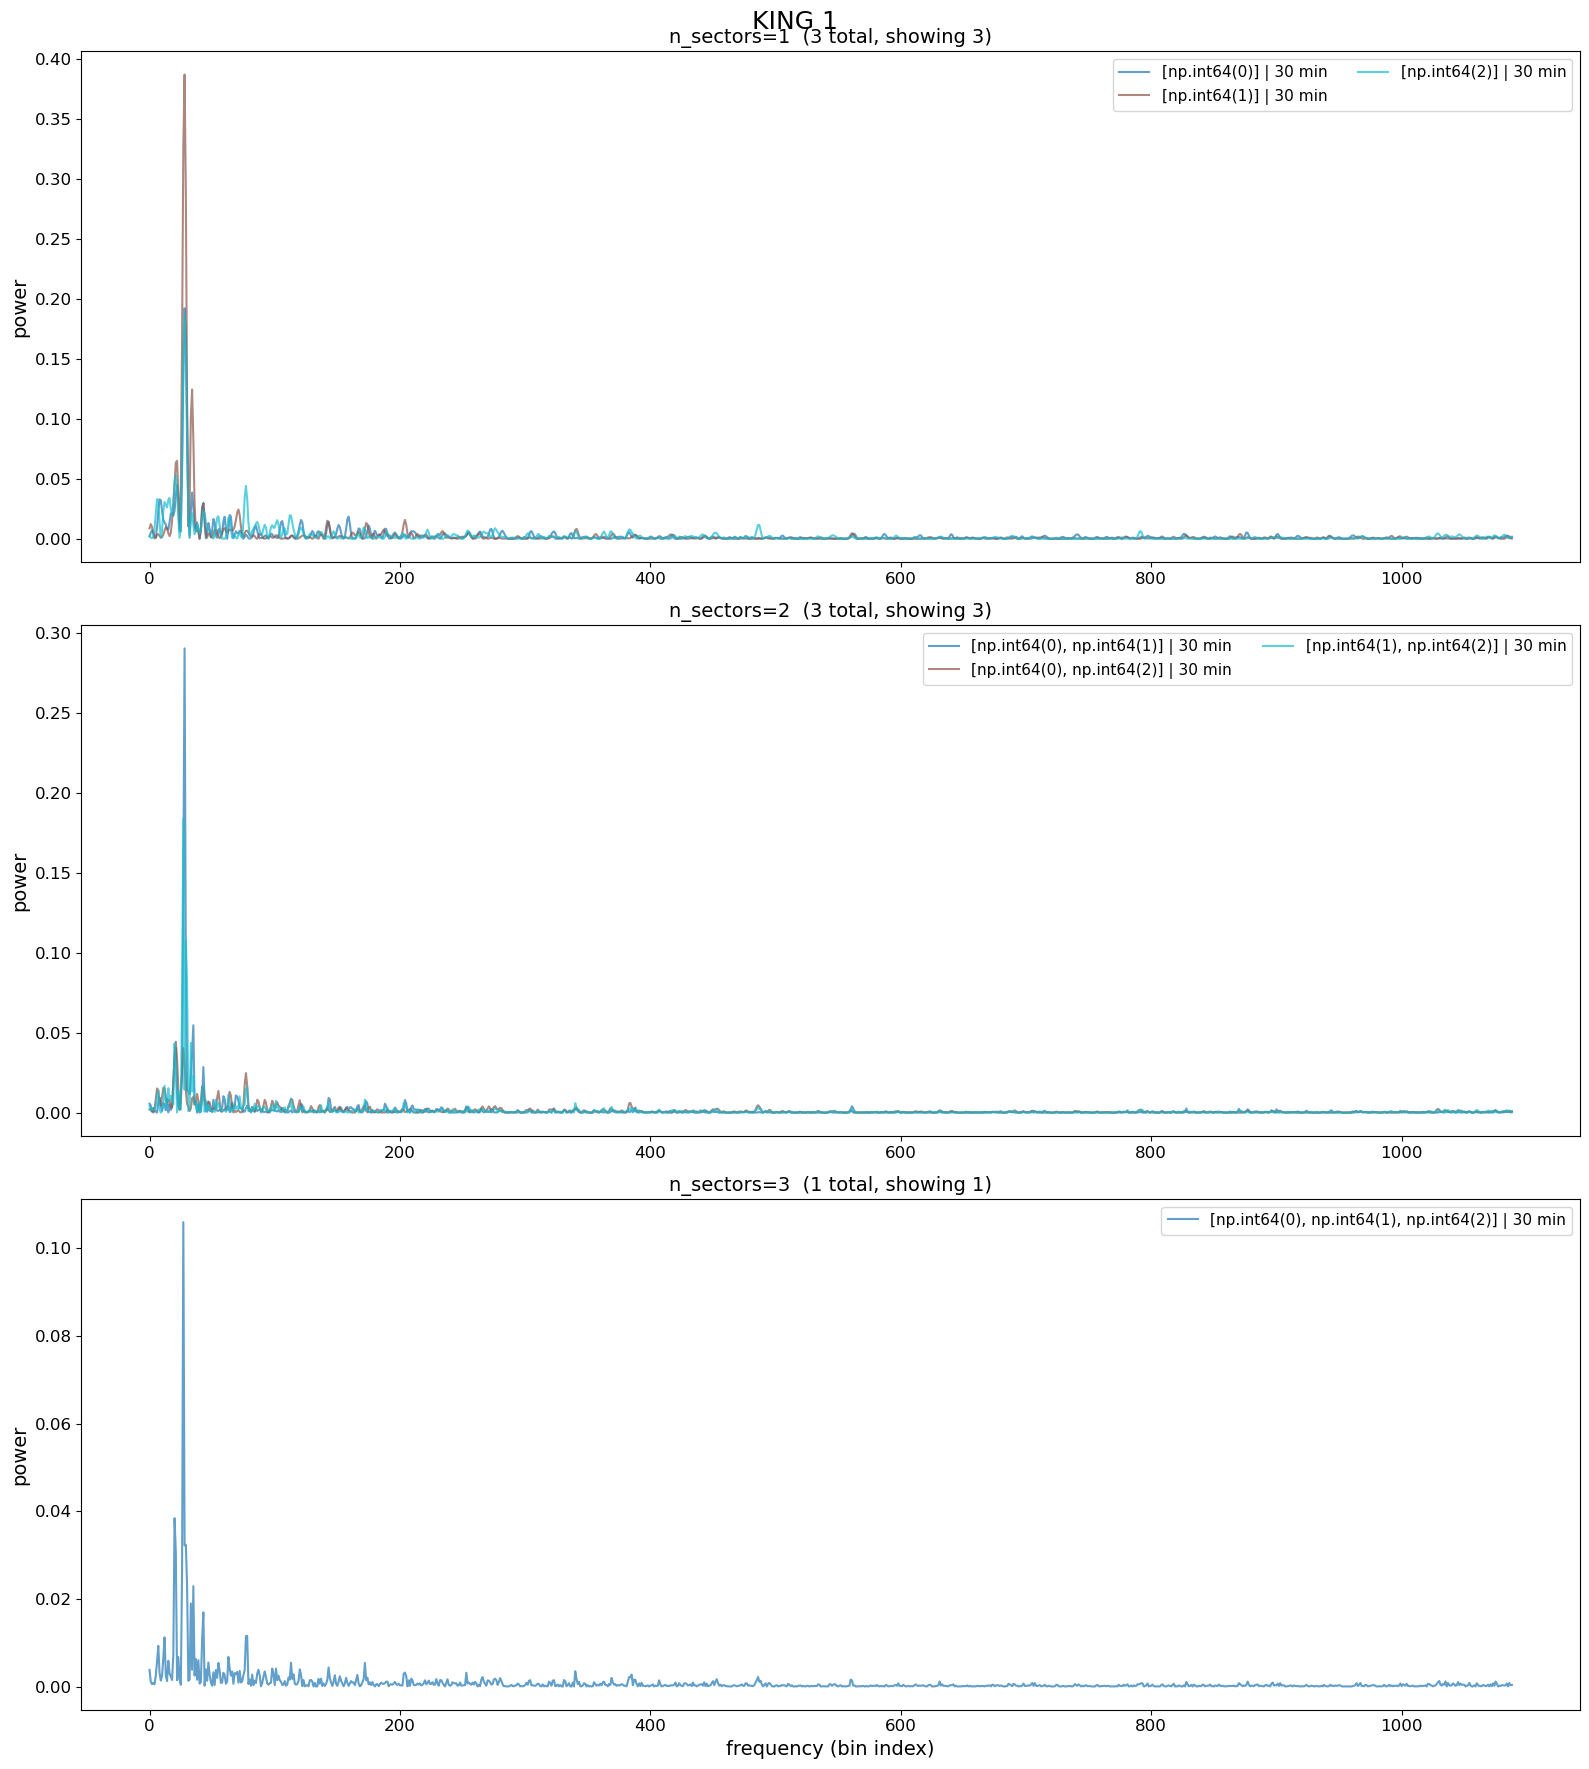

In [134]:
plot_cluster_periodograms(master_table, cluster_name, frequency_bins=None, max_num_pgs=10, yscale='linear', x_lim=[0,200])
plot_cluster_periodograms(master_table, cluster_name, frequency_bins=None, max_num_pgs=10, yscale='linear')

### 

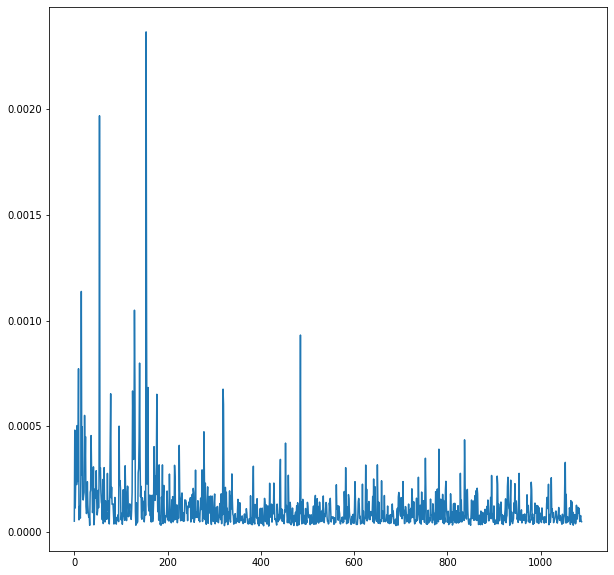

In [99]:
plt.figure(figsize=(10,10))
plt.plot(np.arange(0, len(PG[554]), 1), PG[554])


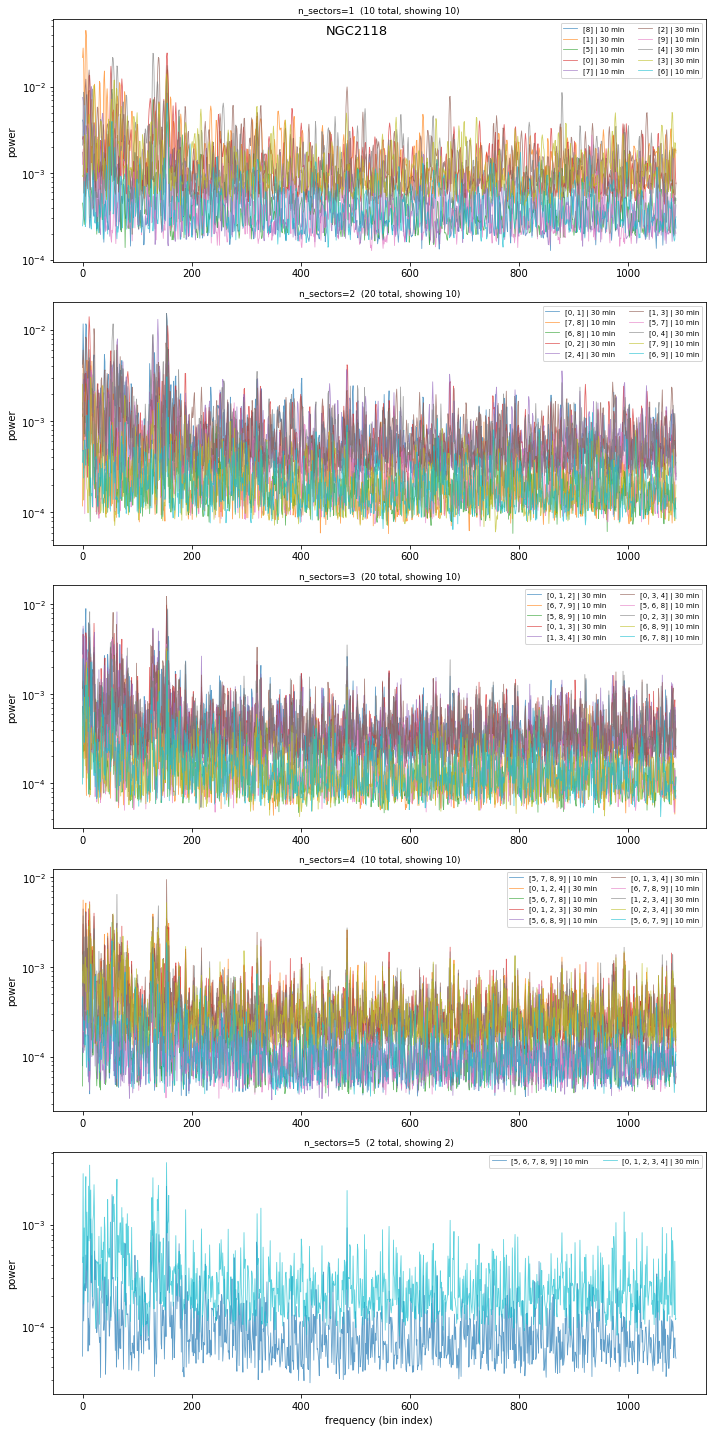

In [175]:
plot_cluster_periodograms(master_table, b'NGC2118', frequency_bins=None, max_num_pgs=10, yscale='log')

In [17]:
#i=master_table['name']==b'NGC2118'
np.whe

0      7.90
1      7.90
2      7.90
3      7.90
4      7.90
       ... 
863    9.20
864    9.20
865    8.91
866    8.91
867    8.91
Name: AGE, Length: 868, dtype: float64

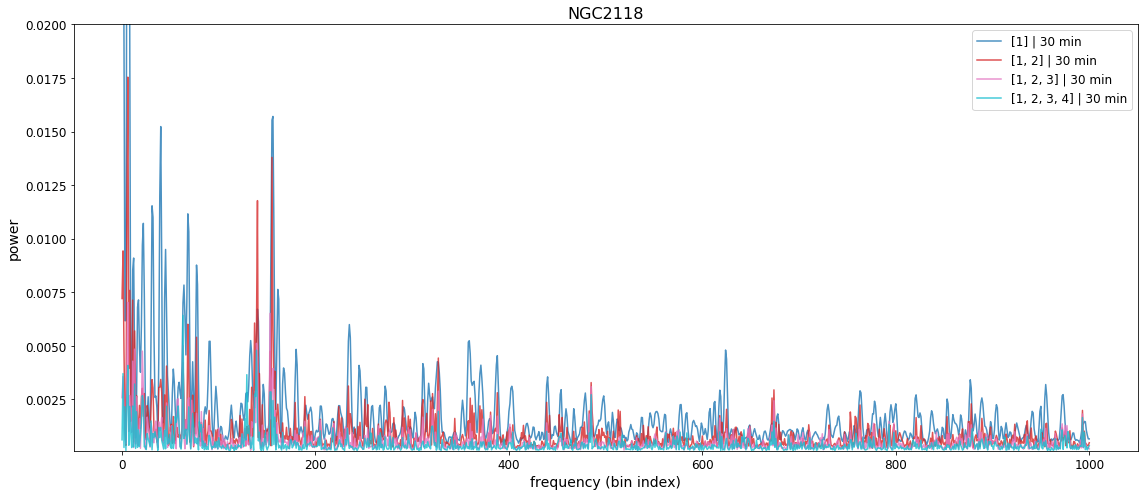

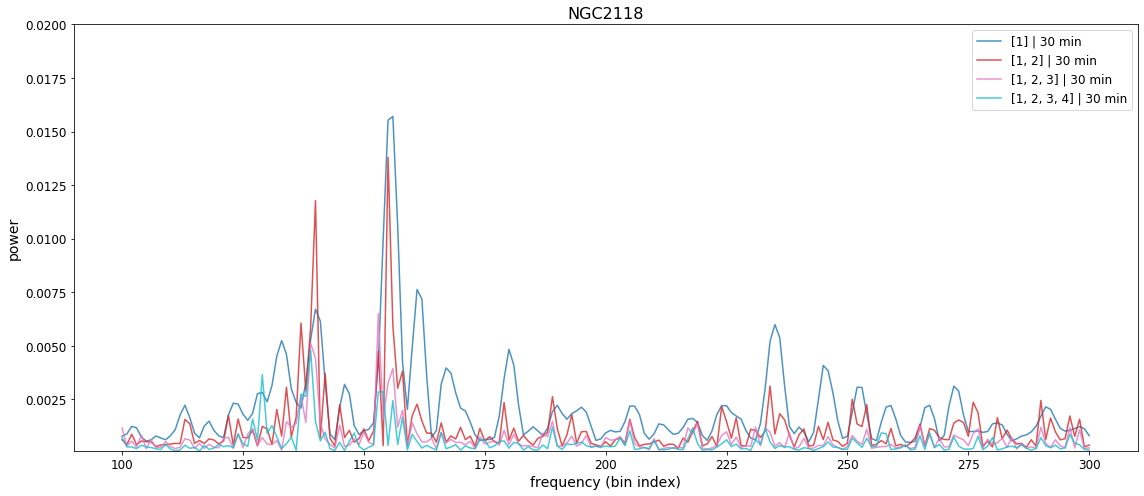

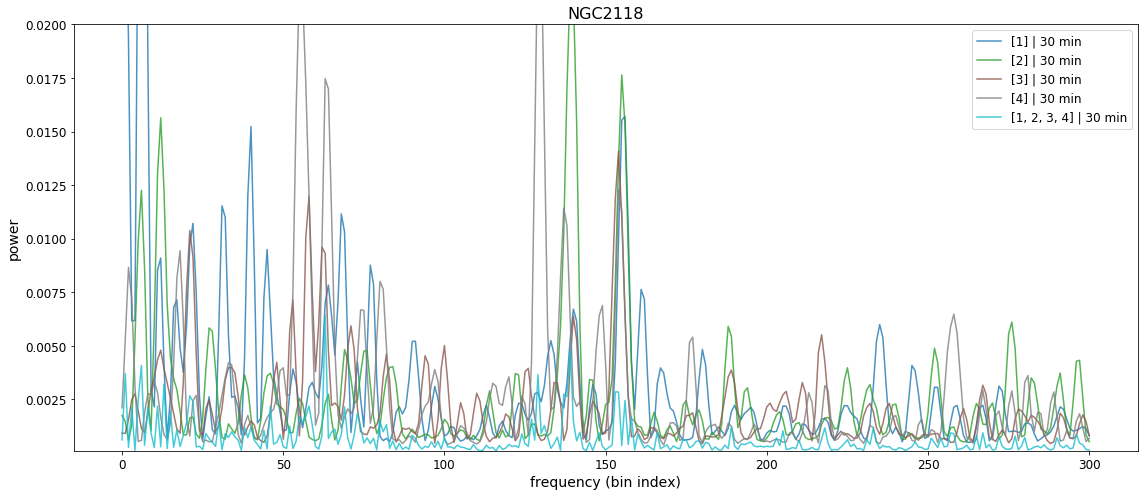

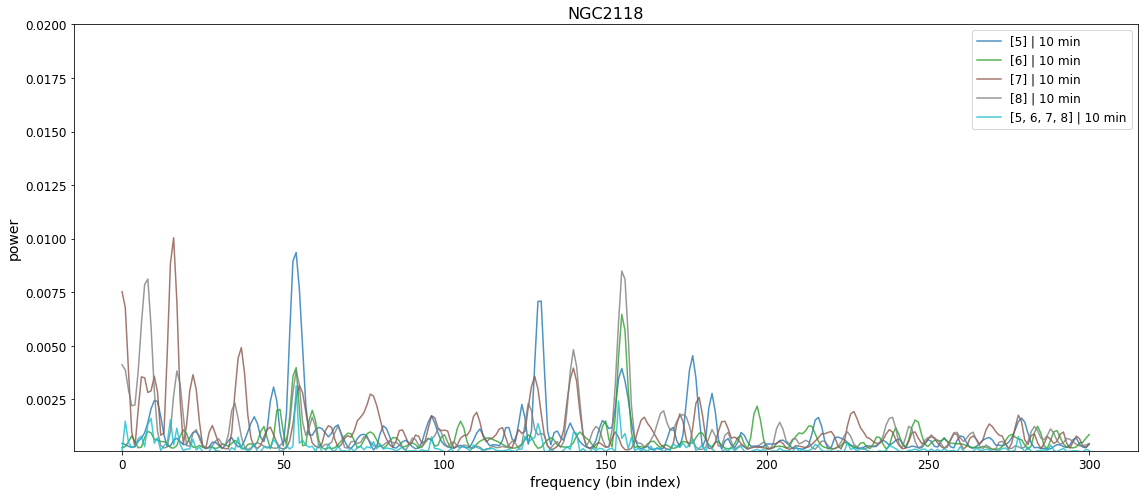

In [31]:


plot_cluster_periodograms_specific(master_table, b'NGC2118', 
                                   sectors_list= [ [1],
                                                  [1,2], 
                                                  [1,2,3], 
                                                  [1,2,3,4], 
                                                ],
                                   frequency_bins=None, 
                                   yscale='linear', y_lim=[1e-4, 2e-2],
                                   xscale='linear', x_lim=(0, 1000),

                                  )

plot_cluster_periodograms_specific(master_table, b'NGC2118', 
                                   sectors_list= [ [1],
                                                  [1,2], 
                                                  [1,2,3], 
                                                  [1,2,3,4], 
                                                ],
                                   frequency_bins=None, 
                                   yscale='linear', y_lim=[1e-4, 2e-2],
                                   xscale='linear', x_lim=(100, 300),

                                  )


plot_cluster_periodograms_specific(master_table, b'NGC2118', 
                                   sectors_list= [ [1],
                                                  [2], 
                                                  [3], 
                                                  [4], 
                                                  [1, 2, 3, 4]
                                                ],
                                   frequency_bins=None, 
                                   yscale='linear', y_lim=[1e-4, 2e-2],
                                   xscale='linear', x_lim=(0, 300),

                                  )


plot_cluster_periodograms_specific(master_table, b'NGC2118', 
                                   sectors_list= [ [5],
                                                  [6], 
                                                  [7], 
                                                  [8], 
                                                  [5,6,7,8],
                                                ],
                                   frequency_bins=None, 
                                   yscale='linear', y_lim=[1e-4, 2e-2],
                                   xscale='linear', x_lim=(0, 300),

                                  )
                                   

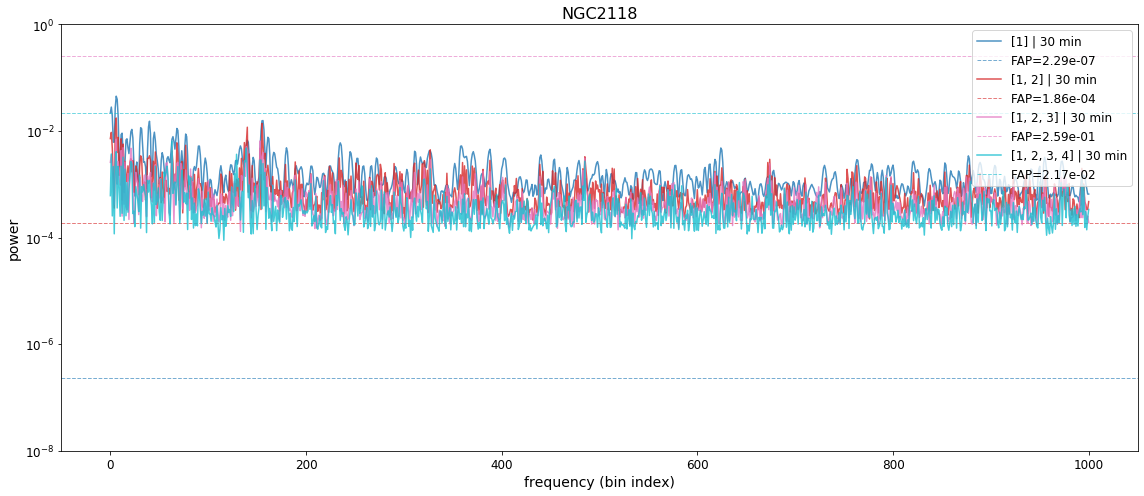

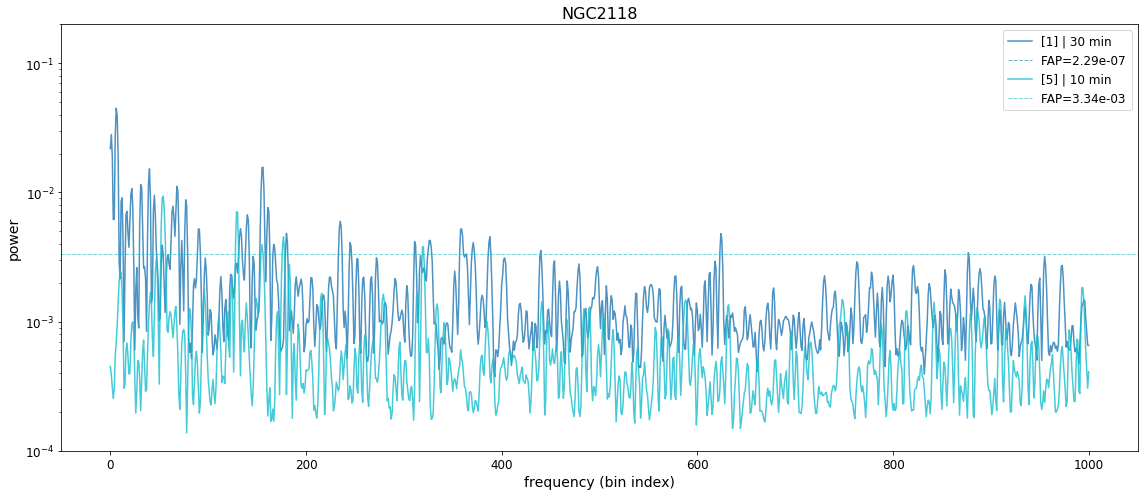

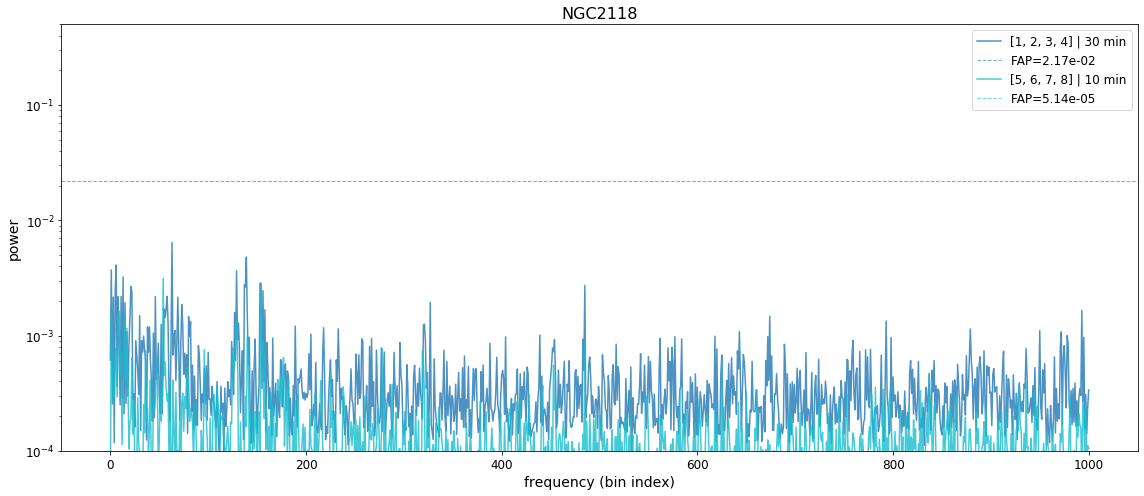

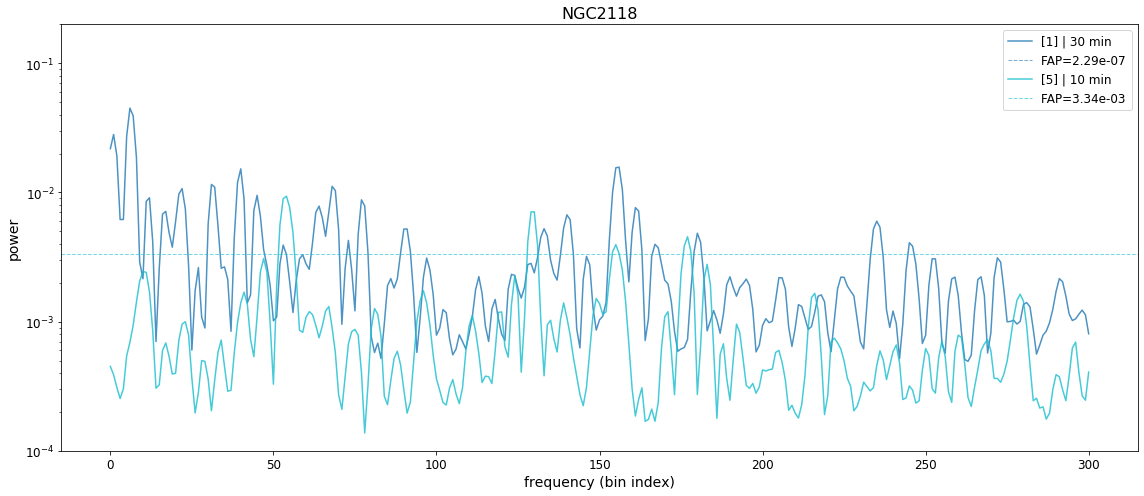

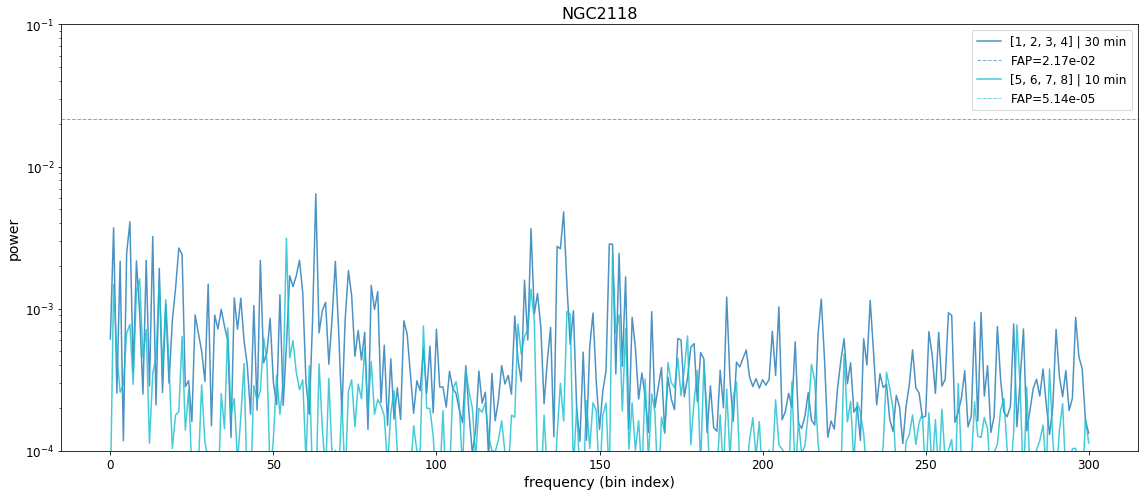

In [47]:


plot_cluster_periodograms_specific(master_table, b'NGC2118', 
                                   sectors_list= [ [1],
                                                  [1,2], 
                                                  [1,2,3], 
                                                  [1,2,3,4], 
                                                ],
                                   frequency_bins=None, 
                                   yscale='log', y_lim=[1e-8, 1],
                                   xscale='linear', x_lim=(0, 1000),

                                  )



plot_cluster_periodograms_specific(master_table, b'NGC2118', 
                                   sectors_list= [ [1],
                                                  [5], 
                                                ],
                                   frequency_bins=None, 
                                   yscale='log', y_lim=[1e-4, 2e-1],
                                   xscale='linear', x_lim=(0, 1000),

                                  )

plot_cluster_periodograms_specific(master_table, b'NGC2118', 
                                   sectors_list= [ [1,2,3,4],
                                                  [5,6,7,8], 
                                                ],
                                   frequency_bins=None, 
                                   yscale='log', y_lim=[1e-4, 5e-1],
                                   xscale='linear', x_lim=(0, 1000),

                                  )


                                  



plot_cluster_periodograms_specific(master_table, b'NGC2118', 
                                   sectors_list= [ [1],
                                                  [5], 
                                                ],
                                   frequency_bins=None, 
                                   yscale='log', y_lim=[1e-4, 2e-1],
                                   xscale='linear', x_lim=(0, 300),

                                  )

plot_cluster_periodograms_specific(master_table, b'NGC2118', 
                                   sectors_list= [ [1,2,3,4],
                                                  [5,6,7,8], 
                                                ],
                                   frequency_bins=None, 
                                   yscale='log', y_lim=[1e-4, 1e-1],
                                   xscale='linear', x_lim=(0, 300),

                                  )


# std_norm: cadence-corrected, noise-subtracted std

In [114]:
from vis_lc import add_std_norm

add_std_norm(master_table)
master_table[['name', 'sectors', 'cadence', 'std', 'std_norm']].head(20)

,name,sectors,cadence,std,std_norm
0,b'BMG32',[0],30.0,0.000668,0.000378
1,b'BMG32',[1],30.0,0.001006,0.000756
2,b'BMG32',[2],30.0,0.001003,0.000707
3,b'BMG32',[3],30.0,0.001056,0.000783
4,b'BMG32',"[0, 1]",30.0,0.000850,0.000599
5,b'BMG32',"[0, 2]",30.0,0.000857,0.000572
6,b'BMG32',"[0, 3]",30.0,0.000900,0.000631
7,b'BMG32',"[1, 2]",30.0,0.001005,0.000735
8,b'BMG32',"[1, 3]",30.0,0.001034,0.000775
9,b'BMG32',"[2, 3]",30.0,0.001031,0.000748


In [115]:
master_table[['name', 'sectors', 'cadence', 'std', 'std_norm']][master_table['name']== b'NGC2118'].head(60)

,name,sectors,cadence,std,std_norm
493,b'NGC2118',[0],30.0,0.000368,0.000130
494,b'NGC2118',[1],30.0,0.000409,0.000209
495,b'NGC2118',[2],30.0,0.000375,0.000155
496,b'NGC2118',[3],30.0,0.000405,0.000133
497,b'NGC2118',[4],30.0,0.000444,0.000214
498,b'NGC2118',"[0, 1]",30.0,0.000388,0.000172
499,b'NGC2118',"[0, 2]",30.0,0.000371,0.000142
500,b'NGC2118',"[0, 3]",30.0,0.000387,0.000131
501,b'NGC2118',"[0, 4]",30.0,0.000409,0.000178
502,b'NGC2118',"[1, 2]",30.0,0.000392,0.000184


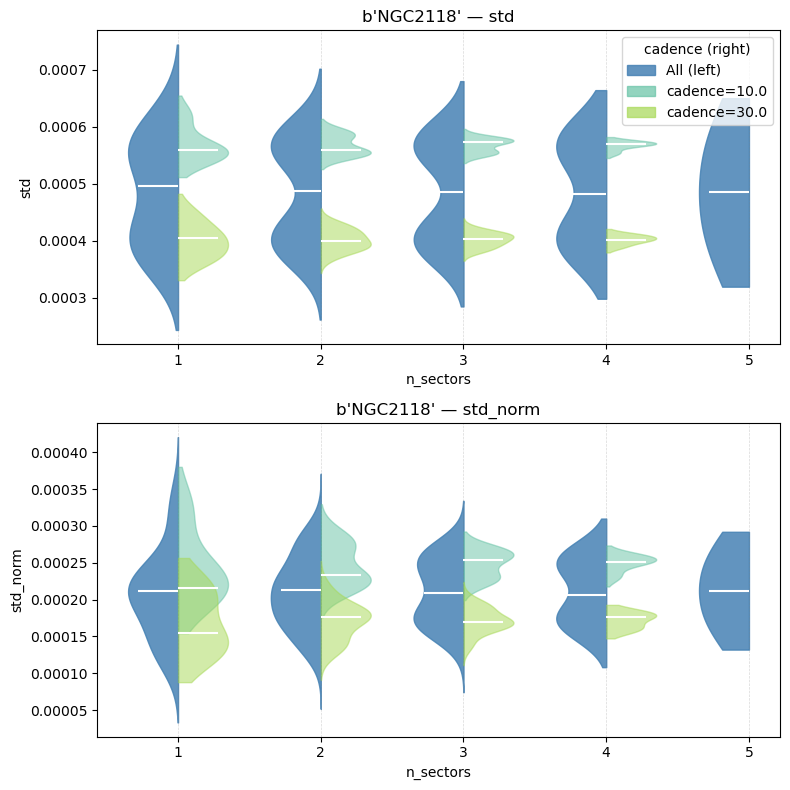

In [116]:
cluster_name = b'NGC2118'
plot_cluster_statistics(
  master_table,
  name=cluster_name,
  statistics_list=['std', 'std_norm'], #, 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio', 'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks', 'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation', 'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power', 'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power', 'Entropy', 'AGE'],
  max_n_sectors=6
)

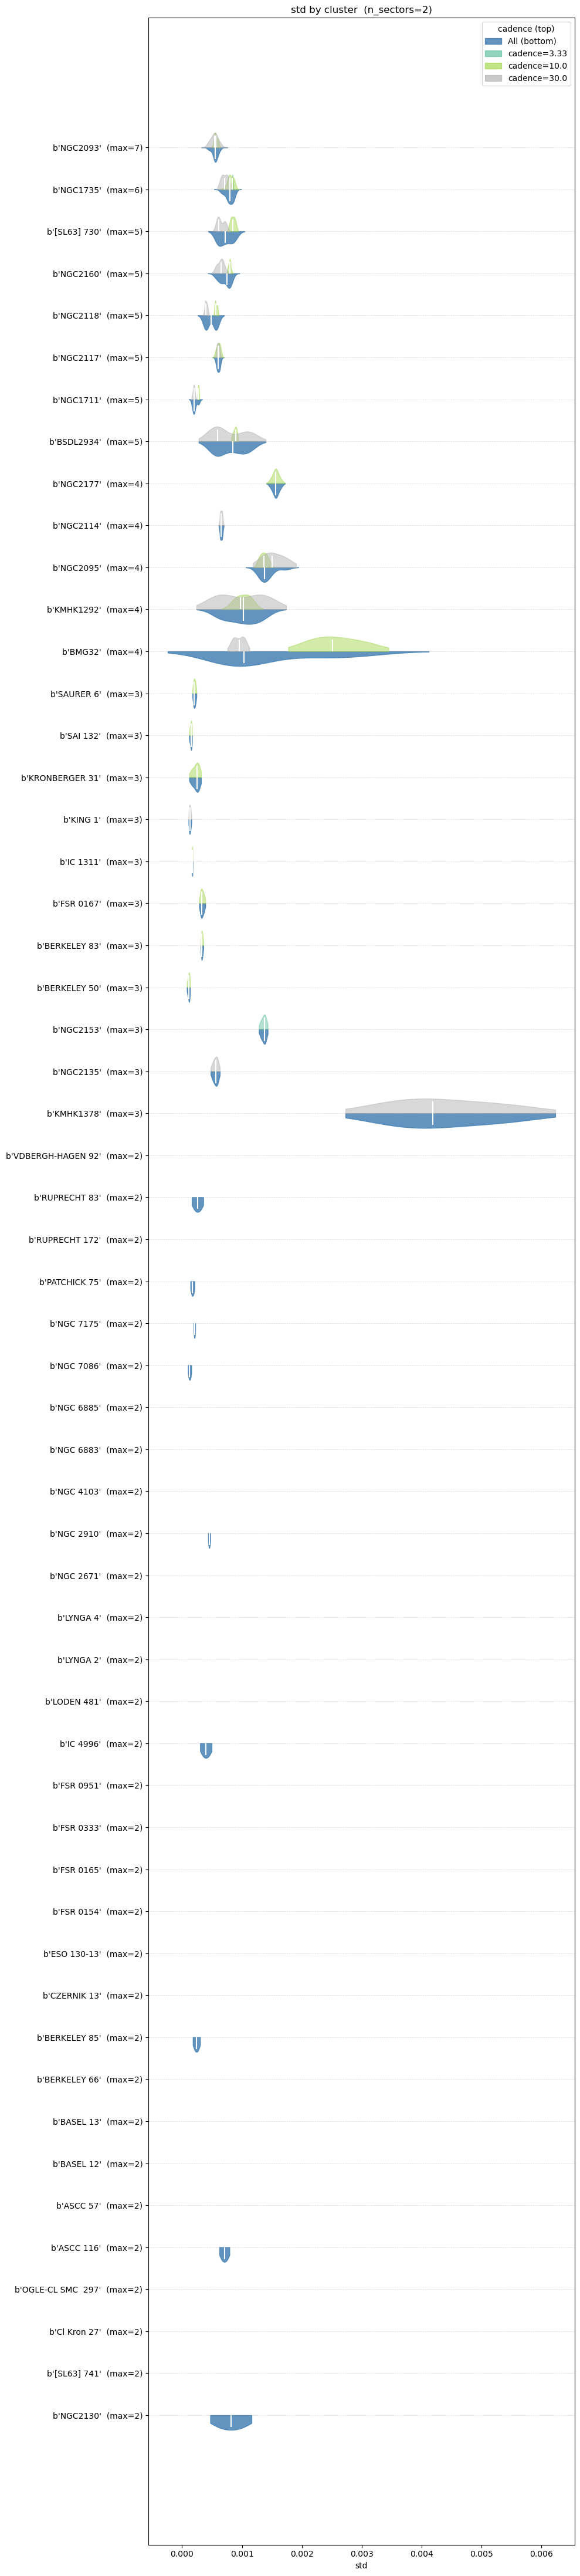

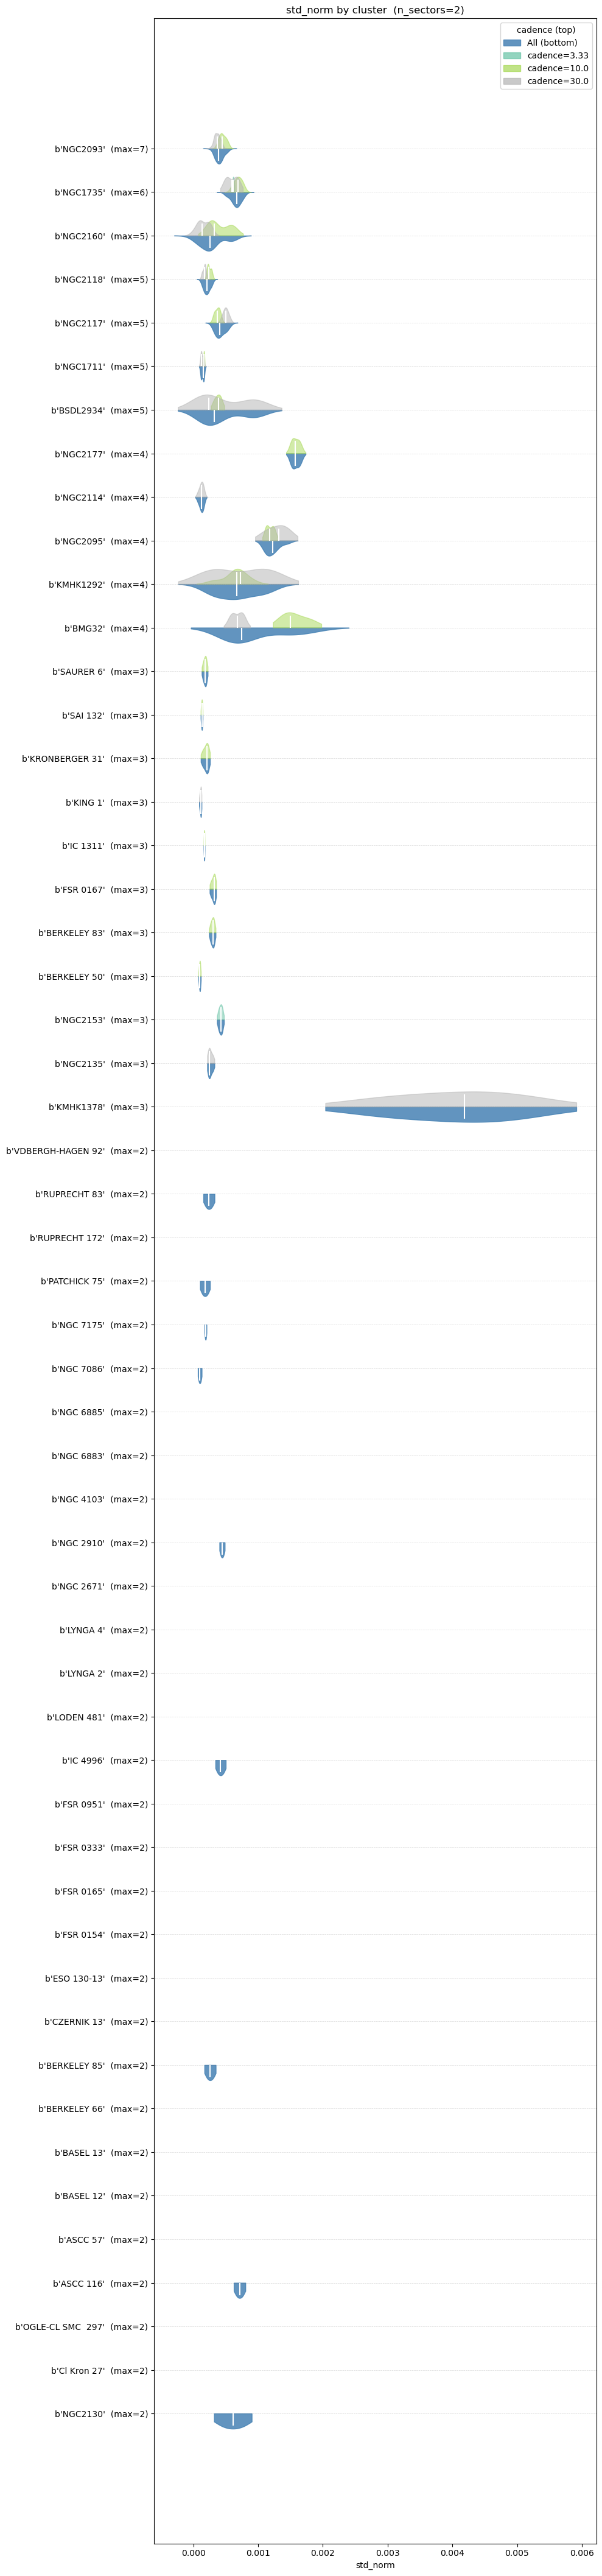

In [117]:
plot_clusters_comparison(master_table, 2, 'std', max_clusters=None)
plot_clusters_comparison(master_table, 2, 'std_norm', max_clusters=None)

In [113]:
# Spot-check: std_norm should generally be <= std (noise subtracted)
check = master_table[['name', 'sectors', 'cadence', 'std', 'std_norm']].copy()
print("Rows where std_norm > std (unexpected):", (check['std_norm'] > check['std']).sum())
print("NaN rows in std_norm:", check['std_norm'].isna().sum())

# Compare 10-min vs 30-min rows for same cluster (should be more similar in std_norm than std)
mixed_cadence_clusters = (
    master_table.groupby('name')['cadence']
    .apply(lambda x: x.nunique() > 1)
)
mixed = mixed_cadence_clusters[mixed_cadence_clusters].index.tolist()
if mixed:
    c = mixed[0]
    print(f"\nCluster with mixed cadence: {c}")
    print(master_table[master_table['name'] == c][['cadence', 'std', 'std_norm']])
else:
    print("\nNo single cluster has mixed cadences (expected — each row is one cadence)")
    # Instead compare across clusters: 10-min vs 30-min
    for cad in [10.0, 30.0]:
        sub = master_table[master_table['cadence'] == cad][['name', 'cadence', 'std', 'std_norm']].head(5)
        print(f"\nCadence={cad}min sample:\n{sub}")

Rows where std_norm > std (unexpected): 627
NaN rows in std_norm: 49

Cluster with mixed cadence: b'ASCC 116'
     cadence       std  std_norm
707    30.00  0.000621  0.000623
708    30.00  0.000696  0.000699
709    30.00  0.000664  0.005269
710     3.33  0.000680  0.000673
711     3.33  0.000816  0.000839
712     3.33  0.000749  0.022436
